In [35]:
import pandas as pd
import numpy as np

accidents = pd.read_csv("../data/processed/Accident_auto_combined.csv")

/var/folders/05/_vxzr9653lg058wd1tp1rdyr0000gn/T/ipykernel_93123/2431587577.py:4: DtypeWarning: Columns (1,2,14,17,21,24,25,27,28,44,46,47,53,54,55,56,59) have mixed types. Specify dtype option on import or set low_memory=False.
  accidents = pd.read_csv("../data/processed/Accident_auto_combined.csv")


In [37]:
accidents['an'].unique()

array([2023, 2022, 2021, 2020, 2019,   18,   17,   16,   15,   14,   13,
         12,   11,   10,    8,    7,    6,    5])

In [3]:
accidents.head()

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,...,atm,col,adr,lat,long,id_vehicule_x,id_vehicule_y,secu,env1,gps
0,202300000001,203 851 184,155 680 557,A01,1.0,1,4,1,1978.0,5.0,...,2.0,7.0,RUE DE RIVOLI,"48,86638600","2,32347100",NaN,NaN,NaN,NaN,NaN
1,202300000001,203 851 184,155 680 557,A01,1.0,1,4,1,1978.0,5.0,...,2.0,7.0,RUE DE RIVOLI,"48,86638600","2,32347100",NaN,NaN,NaN,NaN,NaN
2,202300000002,203 851 182,155 680 556,A01,1.0,1,1,2,1997.0,9.0,...,3.0,6.0,Avenue de Paris,"48,84547782","2,42868146",NaN,NaN,NaN,NaN,NaN
3,202300000002,203 851 183,155 680 556,A01,10.0,3,3,1,1997.0,9.0,...,3.0,6.0,Avenue de Paris,"48,84547782","2,42868146",NaN,NaN,NaN,NaN,NaN
4,202300000003,203 851 180,155 680 554,B01,1.0,1,3,1,1987.0,0.0,...,2.0,1.0,Avenue du Général Leclerc,"48,76240000","2,40655000",NaN,NaN,NaN,NaN,NaN


In [4]:
accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3292075 entries, 0 to 3292074
Data columns (total 60 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Num_Acc        int64  
 1   id_usager      object 
 2   id_vehicule    object 
 3   num_veh        object 
 4   place          float64
 5   catu           int64  
 6   grav           int64  
 7   sexe           int64  
 8   an_nais        float64
 9   trajet         float64
 10  secu1          float64
 11  secu2          float64
 12  secu3          float64
 13  locp           float64
 14  actp           object 
 15  etatp          float64
 16  catr           float64
 17  voie           object 
 18  v1             float64
 19  v2             object 
 20  circ           float64
 21  nbv            object 
 22  vosp           float64
 23  prof           float64
 24  pr             object 
 25  pr1            object 
 26  plan           float64
 27  lartpc         object 
 28  larrout        object 
 29  surf          

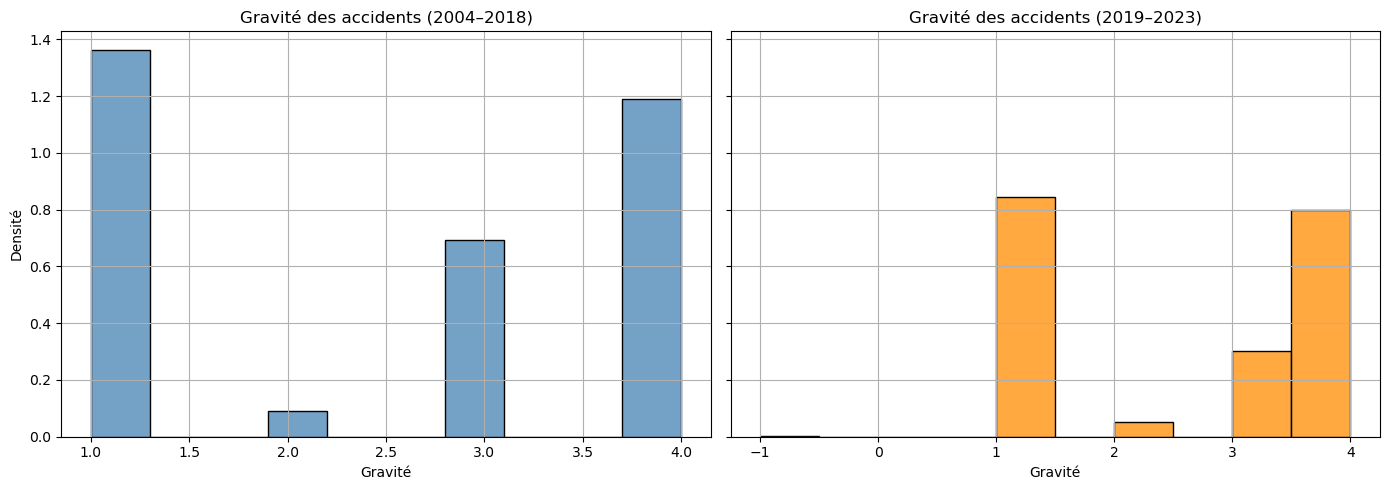

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
accidents['Num_Acc']=accidents['Num_Acc'].astype(str)
accidents['an']= accidents['Num_Acc'].str[:4]
accidents['an']=accidents['an'].astype(int)

# Séparation du DataFrame en deux périodes
accidents_1 = accidents[accidents['an'].between(2004, 2018)]
accidents_2 = accidents[accidents['an'].between(2019, 2023)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Histogramme normalisé pour 2004–2018
sns.histplot(
    accidents_1['grav'], 
    bins=10, 
    stat="density",  # Normalisation
    kde=False, 
    color='steelblue', 
    ax=axes[0]
)
axes[0].set_title("Gravité des accidents (2004–2018)")
axes[0].set_xlabel("Gravité")
axes[0].set_ylabel("Densité")
axes[0].grid(True)

# Histogramme normalisé pour 2019–2023
sns.histplot(
    accidents_2['grav'], 
    bins=10, 
    stat="density",  # Normalisation
    kde=False, 
    color='darkorange', 
    ax=axes[1]
)
axes[1].set_title("Gravité des accidents (2019–2023)")
axes[1].set_xlabel("Gravité")
axes[1].grid(True)

plt.tight_layout()
plt.show()






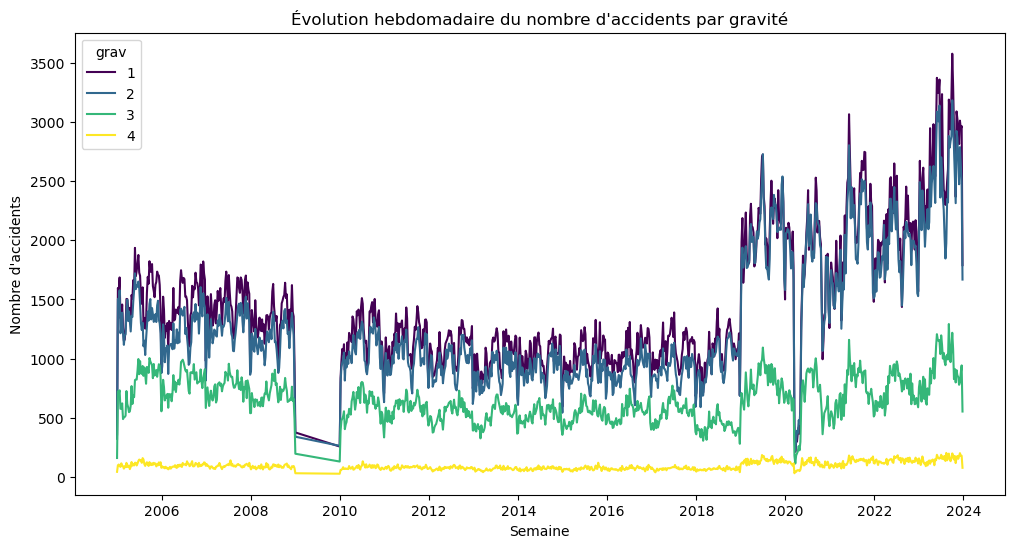

In [39]:
accidents = accidents[accidents['grav'] != -1]
accidents['grav'] = accidents['grav'].replace({2: 42})
accidents['grav'] = accidents['grav'].replace({4: 2})
accidents['grav'] = accidents['grav'].replace({42: 4})

accidents['datetime_string'] = (
    accidents['an'].astype(str) + '-' +
    accidents['mois'].astype(str).str.zfill(2) + '-' +
    accidents['jour'].astype(str).str.zfill(2)
    
)
accidents['date'] = pd.to_datetime(accidents['datetime_string'], format='%Y-%m-%d')

accidents = accidents.drop('datetime_string',axis=1)

accidents['date'] = pd.to_datetime(accidents['date'], errors='coerce')
accidents['week'] = accidents['date'].dt.to_period('W').dt.start_time
accidents_weekly = accidents.groupby(['week', 'grav']).size().reset_index(name='counts')

plt.figure(figsize=(12, 6))
sns.lineplot(data=accidents_weekly, x='week', y='counts', hue='grav', errorbar=('ci', 95), palette='viridis')
plt.title("Évolution hebdomadaire du nombre d'accidents par gravité")
plt.xlabel("Semaine")
plt.ylabel("Nombre d'accidents")

plt.show()

In [22]:
accidents['an'].unique()

array([2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013,
       2012, 2011, 2010, 2008, 2007, 2006, 2005])

In [24]:
accidents_2009 = accidents[accidents['Num_Acc'].str[:4] == 2009]
accidents_2009.head()

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,...,adr,lat,long,id_vehicule_x,id_vehicule_y,secu,env1,gps,date,week
